In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

IMG_SIZE = 224
NUM_CLASSES = 102
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def preprocess(image, label):
    image = tf.image.resize_with_pad(image, IMG_SIZE, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def one_hot(image, label):
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


dataset, info = tfds.load(
    "oxford_flowers102",
    with_info=True,
    as_supervised=True
)

train_ds = dataset["train"].map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = dataset["validation"].map(preprocess, num_parallel_calls=AUTOTUNE)
test_ds_raw = dataset["test"].map(preprocess, num_parallel_calls=AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.12HRU2_2.1.1/oxford_flowers102-test.tfrecord-…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.12HRU2_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.


In [ ]:
def select_first_n_per_class(ds, n=20, num_classes=102):
    counts = {i: 0 for i in range(num_classes)}
    selected_images = []
    selected_labels = []

    for image, label in tfds.as_numpy(ds):
        label_int = int(label)
        if counts[label_int] < n:
            selected_images.append(image)
            selected_labels.append(label_int)
            counts[label_int] += 1

        if all(v >= n for v in counts.values()):
            break

    images = tf.convert_to_tensor(selected_images, dtype=tf.float32)
    labels = tf.convert_to_tensor(selected_labels, dtype=tf.int32)

    return tf.data.Dataset.from_tensor_slices((images, labels))


test_ds = select_first_n_per_class(test_ds_raw, n=20)

In [ ]:
train_ds = (
    train_ds
    .shuffle(2048)
    .map(one_hot, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(one_hot, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(one_hot, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
])

In [ ]:
def build_efficientnet():
    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_tensor=x,
        pooling="avg"
    )

    backbone.trainable = False

    x = tf.keras.layers.Dropout(0.3)(backbone.output)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)
    return model, backbone

In [ ]:
model, backbone = build_efficientnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/PSI5790/efficientnetb0_flowers.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    )
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 175s 5s/step - accuracy: 0.0490 - loss: 4.4827 - val_accuracy: 0.2922 - val_loss: 3.7397
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 201s 5s/step - accuracy: 0.3941 - loss: 3.2923 - val_accuracy: 0.5147 - val_loss: 2.9284
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 207s 5s/step - accuracy: 0.6206 - loss: 2.5045 - val_accuracy: 0.6029 - val_loss: 2.3775
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 198s 5s/step - accuracy: 0.7314 - loss: 1.9484 - val_accuracy: 0.6441 - val_loss: 2.0096
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 159s 5s/step - accuracy: 0.7941 - loss: 1.5495 - val_accuracy: 0.6735 - val_loss: 1.7541
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.8382 - loss: 1.2916 - val_accuracy: 0.7020 - val_loss: 1.5647
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 204s 5s/step - accuracy: 0.8608 - loss: 1.1121 - val_accuracy: 0.7157 - val_loss: 1.4296
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.8814 - loss: 0.9415 - val_accuracy: 0.7539 - v

In [ ]:
backbone.trainable = True

for layer in backbone.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# opcional: congelar parte inicial
for layer in backbone.layers[:180]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 218s 6s/step - accuracy: 0.9922 - loss: 0.1664 - val_accuracy: 0.8363 - val_loss: 0.6827
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 198s 6s/step - accuracy: 0.9902 - loss: 0.1277 - val_accuracy: 0.8343 - val_loss: 0.6695
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 258s 8s/step - accuracy: 0.9784 - loss: 0.1203 - val_accuracy: 0.8353 - val_loss: 0.6647
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 199s 6s/step - accuracy: 0.9912 - loss: 0.0985 - val_accuracy: 0.8412 - val_loss: 0.6536
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 199s 6s/step - accuracy: 0.9873 - loss: 0.0945 - val_accuracy: 0.8422 - val_loss: 0.6467
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 197s 6s/step - accuracy: 0.9971 - loss: 0.0767 - val_accuracy: 0.8412 - val_loss: 0.6390
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 203s 6s/step - accuracy: 0.9902 - loss: 0.0752 - val_accuracy: 0.8422 - val_loss: 0.6299
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 191s 6s/step - accuracy: 0.9902 - loss: 0.0781 - val_accuracy: 0.8422 - v

In [ ]:
def preprocess_vit_base(image, label):
    image = tf.image.resize_with_pad(image, 224, 224)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


train_ds_vit = (
    dataset["train"]
    .map(preprocess_vit_base, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(2048)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_vit = (
    dataset["validation"]
    .map(preprocess_vit_base, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
vit_model, vit_backbone = build_deit_tiny()

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=3e-4,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_vit = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/PSI5790/deit_tiny_flowers.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True
    )
]

vit_model.fit(
    train_ds_vit,
    validation_data=val_ds_vit,
    epochs=40,
    callbacks=callbacks_vit
)

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 247s 7s/step - accuracy: 0.0186 - loss: 5.4106 - val_accuracy: 0.0147 - val_loss: 5.0799
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.0147 - loss: 5.0641 - val_accuracy: 0.0225 - val_loss: 4.8207
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 229s 7s/step - accuracy: 0.0284 - loss: 4.8160 - val_accuracy: 0.0392 - val_loss: 4.6129
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 262s 7s/step - accuracy: 0.0431 - loss: 4.5812 - val_accuracy: 0.0549 - val_loss: 4.4320
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 228s 7s/step - accuracy: 0.0627 - loss: 4.3968 - val_accuracy: 0.0716 - val_loss: 4.2662
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 237s 7s/step - accuracy: 0.0706 - loss: 4.2076 - val_accuracy: 0.1127 - val_loss: 4.1096
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 236s 7s/step - accuracy: 0.1020 - loss: 4.0299 - val_accuracy: 0.1392 - val_loss: 3.9641
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 259s 7s/step - accuracy: 0.1294 - loss: 3.8655 - val_accuracy: 0.1627 - v

In [ ]:
vit_backbone.trainable = True

vit_model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vit_model.fit(
    train_ds_vit,
    validation_data=val_ds_vit,
    epochs=30,
    callbacks=callbacks_vit
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 492s 14s/step - accuracy: 0.8314 - loss: 0.9228 - val_accuracy: 0.7255 - val_loss: 1.2749
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 497s 14s/step - accuracy: 0.8559 - loss: 0.7315 - val_accuracy: 0.7500 - val_loss: 1.1645
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 446s 14s/step - accuracy: 0.8961 - loss: 0.6168 - val_accuracy: 0.7618 - val_loss: 1.1038
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 499s 14s/step - accuracy: 0.9098 - loss: 0.5388 - val_accuracy: 0.7765 - val_loss: 1.0353
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 443s 14s/step - accuracy: 0.9245 - loss: 0.4659 - val_accuracy: 0.7853 - val_loss: 0.9966
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 440s 14s/step - accuracy: 0.9412 - loss: 0.4062 - val_accuracy: 0.7892 - val_loss: 0.9557
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 441s 14s/step - accuracy: 0.9569 - loss: 0.3512 - val_accuracy: 0.8039 - val_loss: 0.9225
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 442s 14s/step - accuracy: 0.9618 - loss: 0.3203 - val_accuracy: 0.

In [1]:
"""
I want to make some plots from the training of each model, Ill send the data I want you to build the array and make this
(copy paste of training prints)
"""

import numpy as np
import matplotlib.pyplot as plt

# =========================
# EfficientNetB0 - head-only
# =========================

eff_head_acc = np.array([
    0.0490, 0.3941, 0.6206, 0.7314, 0.7941, 0.8382, 0.8608, 0.8814,
    0.8961, 0.9078, 0.9333, 0.9422, 0.9422, 0.9529, 0.9569, 0.9676,
    0.9637, 0.9686, 0.9804, 0.9794, 0.9804, 0.9833, 0.9784, 0.9863,
    0.9794, 0.9873, 0.9951, 0.9902, 0.9824, 0.9863, 0.9882, 0.9941,
    0.9902, 0.9882
])

eff_head_loss = np.array([
    4.4827, 3.2923, 2.5045, 1.9484, 1.5495, 1.2916, 1.1121, 0.9415,
    0.8361, 0.7304, 0.6569, 0.5917, 0.5300, 0.5019, 0.4516, 0.4074,
    0.3783, 0.3511, 0.3146, 0.3009, 0.2874, 0.2524, 0.2674, 0.2425,
    0.2339, 0.2086, 0.1968, 0.1899, 0.1895, 0.1889, 0.1677, 0.1574,
    0.1640, 0.1486
])

eff_head_val_acc = np.array([
    0.2922, 0.5147, 0.6029, 0.6441, 0.6735, 0.7020, 0.7157, 0.7539,
    0.7627, 0.7618, 0.7686, 0.7824, 0.7765, 0.7882, 0.8029, 0.7971,
    0.7961, 0.8010, 0.8069, 0.8127, 0.8088, 0.8186, 0.8206, 0.8225,
    0.8196, 0.8314, 0.8294, 0.8255, 0.8255, 0.8265, 0.8314, 0.8294,
    0.8304, 0.8304
])

eff_head_val_loss = np.array([
    3.7397, 2.9284, 2.3775, 2.0096, 1.7541, 1.5647, 1.4296, 1.3098,
    1.2252, 1.1541, 1.0955, 1.0455, 1.0098, 0.9725, 0.9330, 0.9119,
    0.8913, 0.8723, 0.8498, 0.8324, 0.8151, 0.7989, 0.7857, 0.7778,
    0.7687, 0.7527, 0.7371, 0.7287, 0.7256, 0.7197, 0.7201, 0.7054,
    0.6966, 0.6967
])


# =========================
# EfficientNetB0 - fine-tuning
# =========================

eff_ft_acc = np.array([
    0.9922, 0.9902, 0.9784, 0.9912, 0.9873, 0.9971, 0.9902, 0.9902,
    0.9892, 0.9873, 0.9892, 0.9912, 0.9912, 0.9951, 0.9951, 0.9922,
    0.9971
])

eff_ft_loss = np.array([
    0.1664, 0.1277, 0.1203, 0.0985, 0.0945, 0.0767, 0.0752, 0.0781,
    0.0705, 0.0730, 0.0603, 0.0682, 0.0611, 0.0564, 0.0483, 0.0517,
    0.0385
])

eff_ft_val_acc = np.array([
    0.8363, 0.8343, 0.8353, 0.8412, 0.8422, 0.8412, 0.8422, 0.8422,
    0.8471, 0.8461, 0.8461, 0.8471, 0.8471, 0.8461, 0.8422, 0.8451,
    0.8471
])

eff_ft_val_loss = np.array([
    0.6827, 0.6695, 0.6647, 0.6536, 0.6467, 0.6390, 0.6299, 0.6264,
    0.6204, 0.6202, 0.6171, 0.6121, 0.6051, 0.6046, 0.6110, 0.6061,
    0.6055
])

Total epochs: 51
Fine-tuning starts at epoch: 35
Best val accuracy: 0.8471
Best val accuracy epoch: 43
Best val loss: 0.6046
Best val loss epoch: 48


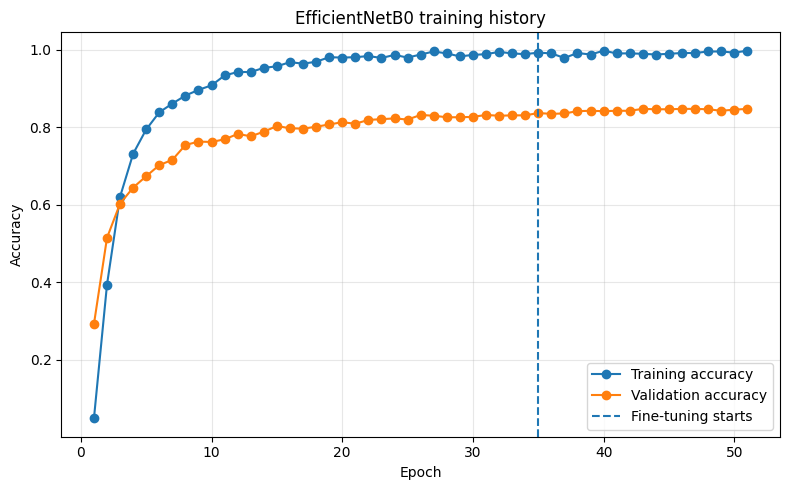

In [2]:
eff_acc = np.concatenate([eff_head_acc, eff_ft_acc])
eff_loss = np.concatenate([eff_head_loss, eff_ft_loss])
eff_val_acc = np.concatenate([eff_head_val_acc, eff_ft_val_acc])
eff_val_loss = np.concatenate([eff_head_val_loss, eff_ft_val_loss])

epochs = np.arange(1, len(eff_acc) + 1)
ft_start_epoch = len(eff_head_acc) + 1

print("Total epochs:", len(epochs))
print("Fine-tuning starts at epoch:", ft_start_epoch)
print("Best val accuracy:", eff_val_acc.max())
print("Best val accuracy epoch:", epochs[np.argmax(eff_val_acc)])
print("Best val loss:", eff_val_loss.min())
print("Best val loss epoch:", epochs[np.argmin(eff_val_loss)])

plt.figure(figsize=(8, 5))

plt.plot(epochs, eff_acc, marker="o", label="Training accuracy")
plt.plot(epochs, eff_val_acc, marker="o", label="Validation accuracy")

plt.axvline(
    ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetB0 training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

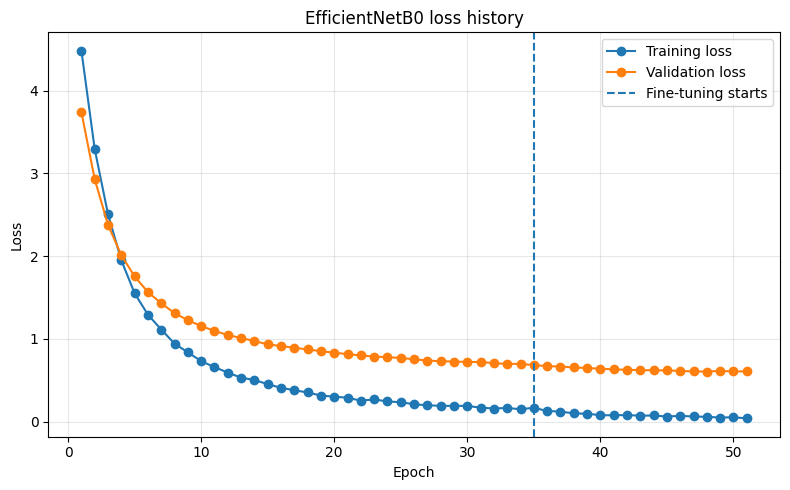

In [3]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, eff_loss, marker="o", label="Training loss")
plt.plot(epochs, eff_val_loss, marker="o", label="Validation loss")

plt.axvline(
    ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNetB0 loss history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

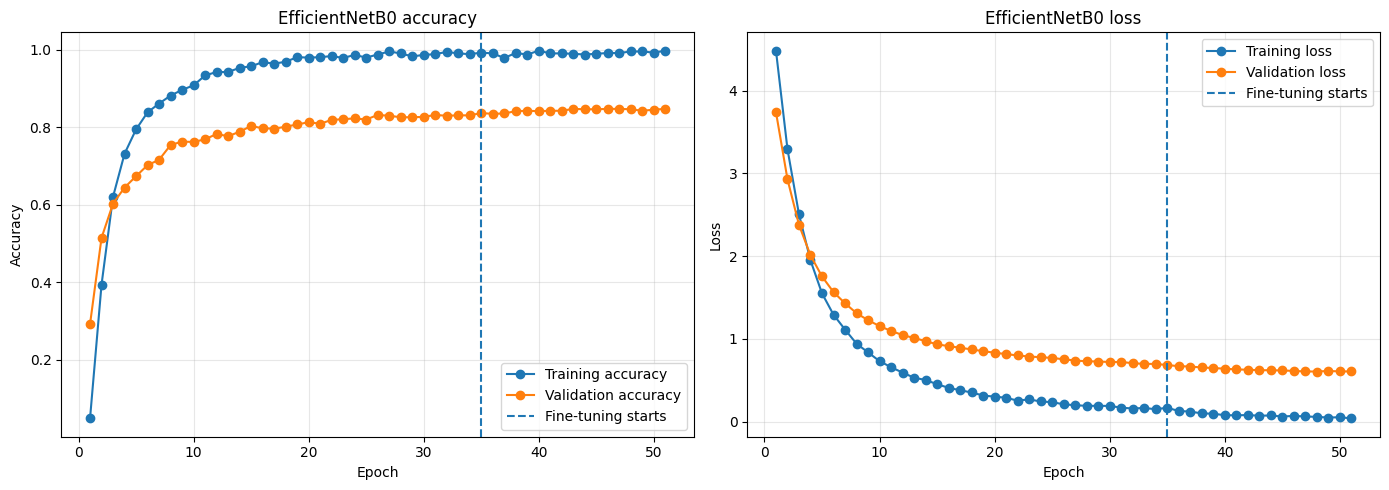

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, eff_acc, marker="o", label="Training accuracy")
axes[0].plot(epochs, eff_val_acc, marker="o", label="Validation accuracy")
axes[0].axvline(ft_start_epoch, linestyle="--", label="Fine-tuning starts")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("EfficientNetB0 accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, eff_loss, marker="o", label="Training loss")
axes[1].plot(epochs, eff_val_loss, marker="o", label="Validation loss")
axes[1].axvline(ft_start_epoch, linestyle="--", label="Fine-tuning starts")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("EfficientNetB0 loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DeiT-Tiny / ViT - head-only
# =========================

vit_head_acc = np.array([
    0.0186, 0.0147, 0.0284, 0.0431, 0.0627, 0.0706, 0.1020, 0.1294,
    0.1588, 0.2000, 0.2431, 0.2588, 0.2853, 0.3510, 0.3520, 0.3882,
    0.4559, 0.4637, 0.4951, 0.5118, 0.5598, 0.5686, 0.5725, 0.6294,
    0.6176, 0.6520, 0.6500, 0.6931, 0.6912, 0.6961, 0.6922, 0.7157,
    0.7500, 0.7343, 0.7422, 0.7725, 0.7902, 0.7824, 0.7961, 0.8000
])

vit_head_loss = np.array([
    5.4106, 5.0641, 4.8160, 4.5812, 4.3968, 4.2076, 4.0299, 3.8655,
    3.7407, 3.5645, 3.4130, 3.2846, 3.1721, 3.0501, 2.9374, 2.8223,
    2.6746, 2.5790, 2.5203, 2.4039, 2.2973, 2.2094, 2.1464, 2.0445,
    1.9744, 1.9058, 1.8546, 1.7350, 1.6970, 1.6565, 1.6026, 1.5588,
    1.4887, 1.4465, 1.3877, 1.3587, 1.3039, 1.2547, 1.2172, 1.1863
])

vit_head_val_acc = np.array([
    0.0147, 0.0225, 0.0392, 0.0549, 0.0716, 0.1127, 0.1392, 0.1627,
    0.1863, 0.2245, 0.2559, 0.2794, 0.3059, 0.3284, 0.3569, 0.3882,
    0.4157, 0.4382, 0.4569, 0.4706, 0.4961, 0.5157, 0.5343, 0.5608,
    0.5686, 0.5843, 0.5902, 0.6039, 0.6069, 0.6186, 0.6314, 0.6392,
    0.6529, 0.6569, 0.6647, 0.6706, 0.6794, 0.6853, 0.6863, 0.6990
])

vit_head_val_loss = np.array([
    5.0799, 4.8207, 4.6129, 4.4320, 4.2662, 4.1096, 3.9641, 3.8258,
    3.6972, 3.5676, 3.4472, 3.3305, 3.2211, 3.1141, 3.0130, 2.9158,
    2.8217, 2.7330, 2.6464, 2.5647, 2.4872, 2.4127, 2.3407, 2.2747,
    2.2114, 2.1491, 2.0917, 2.0354, 1.9824, 1.9339, 1.8862, 1.8394,
    1.7970, 1.7558, 1.7179, 1.6800, 1.6429, 1.6069, 1.5766, 1.5465
])


# =========================
# DeiT-Tiny / ViT - fine-tuning
# =========================

vit_ft_acc = np.array([
    0.8314, 0.8559, 0.8961, 0.9098, 0.9245, 0.9412, 0.9569, 0.9618,
    0.9637, 0.9716, 0.9882, 0.9873, 0.9873, 0.9873, 0.9922, 0.9951,
    0.9941, 0.9941, 0.9971, 1.0000, 0.9980, 0.9990, 0.9971, 0.9980,
    1.0000, 1.0000, 1.0000, 0.9990, 1.0000
])

vit_ft_loss = np.array([
    0.9228, 0.7315, 0.6168, 0.5388, 0.4659, 0.4062, 0.3512, 0.3203,
    0.2882, 0.2654, 0.2182, 0.2096, 0.2049, 0.1903, 0.1700, 0.1446,
    0.1405, 0.1299, 0.1174, 0.1186, 0.1073, 0.0996, 0.0931, 0.0861,
    0.0843, 0.0791, 0.0738, 0.0727, 0.0699
])

vit_ft_val_acc = np.array([
    0.7255, 0.7500, 0.7618, 0.7765, 0.7853, 0.7892, 0.8039, 0.7990,
    0.8078, 0.8137, 0.8118, 0.8186, 0.8216, 0.8176, 0.8245, 0.8284,
    0.8363, 0.8382, 0.8343, 0.8333, 0.8490, 0.8461, 0.8461, 0.8461,
    0.8480, 0.8461, 0.8431, 0.8422, 0.8451
])

vit_ft_val_loss = np.array([
    1.2749, 1.1645, 1.1038, 1.0353, 0.9966, 0.9557, 0.9225, 0.9094,
    0.8797, 0.8601, 0.8434, 0.8332, 0.8037, 0.8107, 0.7857, 0.7703,
    0.7548, 0.7524, 0.7437, 0.7454, 0.7239, 0.7151, 0.7070, 0.7018,
    0.6960, 0.6973, 0.6871, 0.6790, 0.6841
])

In [6]:
vit_acc = np.concatenate([vit_head_acc, vit_ft_acc])
vit_loss = np.concatenate([vit_head_loss, vit_ft_loss])
vit_val_acc = np.concatenate([vit_head_val_acc, vit_ft_val_acc])
vit_val_loss = np.concatenate([vit_head_val_loss, vit_ft_val_loss])

vit_epochs = np.arange(1, len(vit_acc) + 1)
vit_ft_start_epoch = len(vit_head_acc) + 1

print("Total epochs:", len(vit_epochs))
print("Fine-tuning starts at epoch:", vit_ft_start_epoch)
print("Best val accuracy:", vit_val_acc.max())
print("Best val accuracy epoch:", vit_epochs[np.argmax(vit_val_acc)])
print("Best val loss:", vit_val_loss.min())
print("Best val loss epoch:", vit_epochs[np.argmin(vit_val_loss)])

Total epochs: 69
Fine-tuning starts at epoch: 41
Best val accuracy: 0.849
Best val accuracy epoch: 61
Best val loss: 0.679
Best val loss epoch: 68


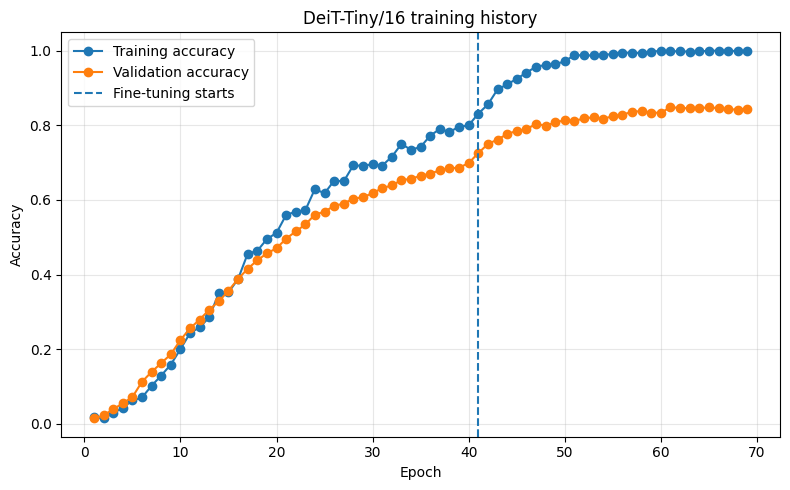

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(vit_epochs, vit_acc, marker="o", label="Training accuracy")
plt.plot(vit_epochs, vit_val_acc, marker="o", label="Validation accuracy")

plt.axvline(
    vit_ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DeiT-Tiny/16 training history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

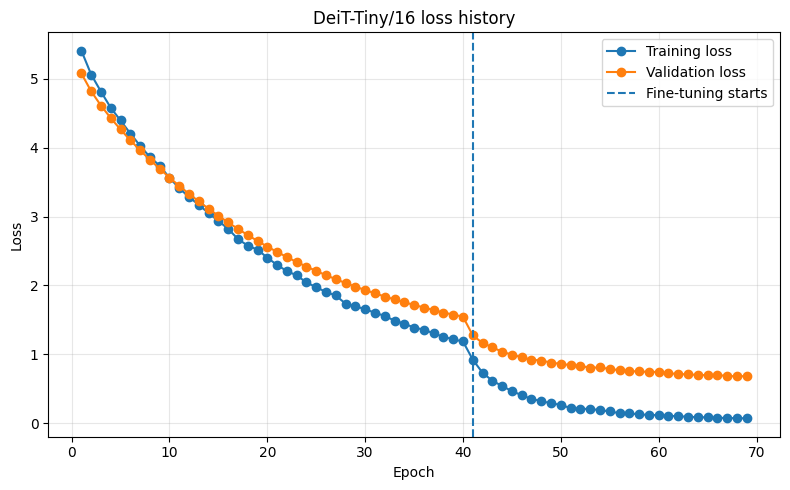

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(vit_epochs, vit_loss, marker="o", label="Training loss")
plt.plot(vit_epochs, vit_val_loss, marker="o", label="Validation loss")

plt.axvline(
    vit_ft_start_epoch,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DeiT-Tiny/16 loss history")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

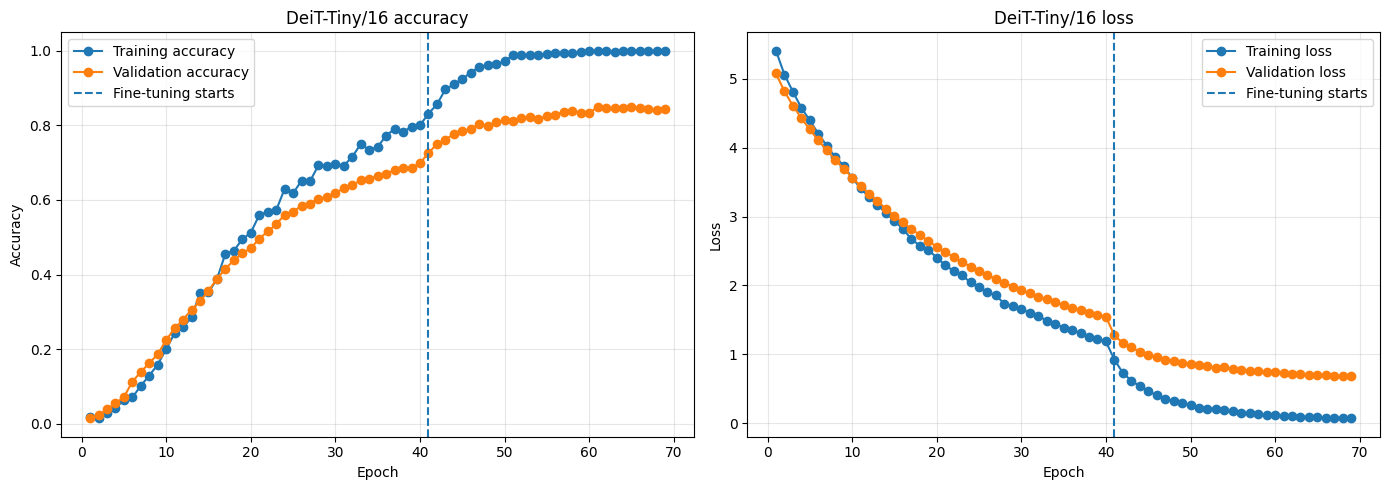

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vit_epochs, vit_acc, marker="o", label="Training accuracy")
axes[0].plot(vit_epochs, vit_val_acc, marker="o", label="Validation accuracy")
axes[0].axvline(vit_ft_start_epoch, linestyle="--", label="Fine-tuning starts")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("DeiT-Tiny/16 accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(vit_epochs, vit_loss, marker="o", label="Training loss")
axes[1].plot(vit_epochs, vit_val_loss, marker="o", label="Validation loss")
axes[1].axvline(vit_ft_start_epoch, linestyle="--", label="Fine-tuning starts")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("DeiT-Tiny/16 loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()